<a href="https://colab.research.google.com/github/cuttestfox/ResNet50_Wafer_Map_Recognition/blob/main/wafer_defect_recognition_vit_torch_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wafer Defect Recognition with Vision Transformer — PyTorch / Google Colab

本 Notebook 將原本的 **TensorFlow / Keras Visual Transformer** 版本改寫成 **PyTorch**，並依照 `ResNet50_Wafer_Map_Recognition.ipynb` 的 Colab 風格，使用 `kagglehub` 下載 MixedWM38 資料集。

### 與原 TensorFlow Notebook 對應的設定
- Dataset：MixedWM38 / `Wafer_Map_Datasets.npz`
- Input：52 × 52 × 1 wafer map
- Patch size：13 × 13 → 16 patches
- Projection dimension：96
- Multi-head attention：4 heads
- Transformer blocks：16
- Transformer MLP：192 → 96
- Classifier MLP：2048 → 1024
- Output：8 個 defect labels，多標籤（multi-label）
- Loss：`BCEWithLogitsLoss`
- Optimizer：Adam + exponential learning-rate decay
- Model checkpoint：保存 validation accuracy 最佳權重

> 原始 TensorFlow notebook 的 `sigmoid + binary_crossentropy` 在 PyTorch 中對應為 `BCEWithLogitsLoss`，模型最後一層不再手動套 sigmoid；只有在 prediction / evaluation 時才使用 sigmoid。


## 1. Install / Import Libraries

在 Colab 執行。`kagglehub` 用來下載公開 Kaggle Dataset，因此不需要使用 Kaggle Notebook 的 `/kaggle/input/...` 路徑。

In [ ]:
!pip -q install kagglehub

import os
import ast
import copy
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import kagglehub

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch: 2.11.0+cu128
CUDA available: True
Using device: cuda


## 2. Download MixedWM38 Dataset

這裡沿用參考的 `ResNet50_Wafer_Map_Recognition.ipynb` 使用 `kagglehub.dataset_download()` 的方式。

Dataset：`co1d7era/mixedtype-wafer-defect-datasets`

In [ ]:
mixedtype_path = kagglehub.dataset_download(
    "co1d7era/mixedtype-wafer-defect-datasets"
)

print("Downloaded dataset:", mixedtype_path)

# Find the NPZ file robustly, so the notebook is not tied to one exact
# kagglehub directory structure.
dataset_path = None
for root, _, files in os.walk(mixedtype_path):
    for f in files:
        if f == "Wafer_Map_Datasets.npz":
            dataset_path = os.path.join(root, f)
            break
    if dataset_path is not None:
        break

if dataset_path is None:
    raise FileNotFoundError("Wafer_Map_Datasets.npz was not found.")

print("Dataset file:", dataset_path)


Using Colab cache for faster access to the 'mixedtype-wafer-defect-datasets' dataset.
Downloaded dataset: /kaggle/input/mixedtype-wafer-defect-datasets
Dataset file: /kaggle/input/mixedtype-wafer-defect-datasets/Wafer_Map_Datasets.npz


## 3. Load Dataset and Inspect Labels

MixedWM38 的 `arr_0` 是 wafer map，`arr_1` 是 8 維 multi-hot defect label。

Label 順序沿用原始 TensorFlow Notebook：

1. Center
2. Donut
3. Edge_Loc
4. Edge_Ring
5. Loc
6. Near_Full
7. Scratch
8. Random

若 8 個 label 全為 0，代表 `Normal wafer`。

In [ ]:
class WaferDataLoader:
    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.label_keys = [
            "Center", "Donut", "Edge_Loc", "Edge_Ring",
            "Loc", "Near_Full", "Scratch", "Random"
        ]

    def load_data(self):
        data = np.load(self.dataset_path)
        self.images = data["arr_0"]
        self.labels = data["arr_1"].astype(np.float32)

        print("MixedWM38:", len(self.labels), "wafers")
        print("Image shape:", self.images.shape)
        print("Label shape:", self.labels.shape)

        return self.images, self.labels

    def read_label(self, label):
        label = np.asarray(label)
        if np.sum(label) == 0:
            return "Normal wafer"

        names = [
            name for name, value in zip(self.label_keys, label)
            if value == 1
        ]
        return ", ".join(names)

data_loader = WaferDataLoader(dataset_path)
images, labels = data_loader.load_data()


MixedWM38: 38015 wafers
Image shape: (38015, 52, 52)
Label shape: (38015, 8)


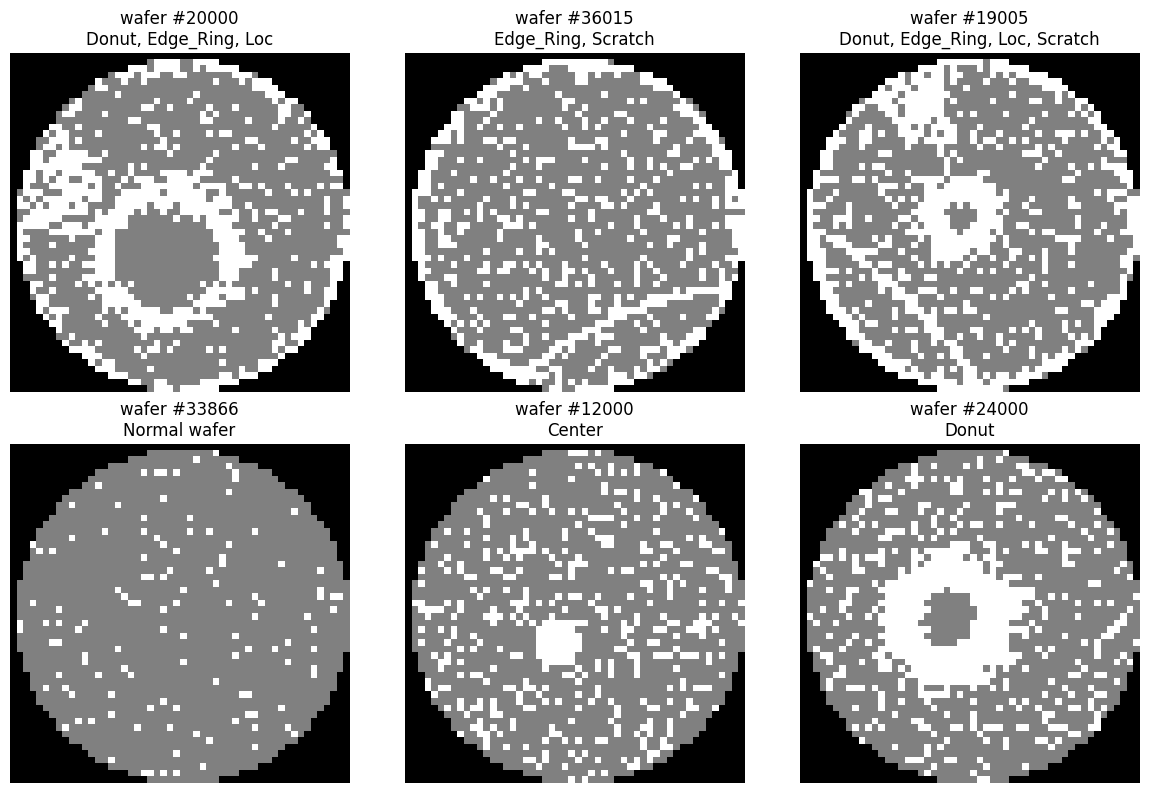

In [ ]:
# Show several examples from the original dataset
sample_indices = [20000, 36015, 19005, 33866, 12000, 24000]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.ravel(), sample_indices):
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"wafer #{idx}\n{data_loader.read_label(labels[idx])}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Train / Validation / Test Split

原始 TensorFlow Notebook：
- 第一次 `train_test_split(..., test_size=0.2)` → 80% train、20% test
- Keras `validation_split=0.1` → 再從 80% train 中取 10% 作 validation

因此下面保留相同概念：
- 72% training
- 8% validation
- 20% test

`random_state=42` 是為了讓 Colab 每次重新執行時比較容易重現結果。

In [ ]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

x_train, x_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.20,
    random_state=SEED
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.10,
    random_state=SEED
)

print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)


Train: (27370, 52, 52) (27370, 8)
Validation: (3042, 52, 52) (3042, 8)
Test: (7603, 52, 52) (7603, 8)


## 5. PyTorch Dataset

原始資料是 52 × 52 wafer map，因此不需要 Resize。

另外，這裡刻意**不使用 `ToTensor()` 的 uint8 0~255 scaling**，因為原始 TensorFlow notebook 直接把 wafer map 的 0 / 1 / 2 數值送進模型。PyTorch 版本也保留相同的數值範圍。

In [ ]:
class WaferDataset(Dataset):
    def __init__(self, images, labels):
        self.images = np.asarray(images)
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.float32)

        # [H, W] -> [1, H, W]
        image = torch.from_numpy(image).unsqueeze(0)

        label = torch.from_numpy(self.labels[idx])
        return image, label


train_dataset = WaferDataset(x_train, y_train)
val_dataset = WaferDataset(x_val, y_val)
test_dataset = WaferDataset(x_test, y_test)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available()
)

sample_x, sample_y = next(iter(train_loader))
print("Batch image:", sample_x.shape)
print("Batch label:", sample_y.shape)


Batch image: torch.Size([128, 1, 52, 52])
Batch label: torch.Size([128, 8])


## 6. Visualize ViT Patches

原始 TensorFlow 模型使用：
- Image size = 52 × 52
- Patch size = 13 × 13
- `52 // 13 = 4`
- 因此每張 wafer 有 `4 × 4 = 16` patches。

Image size: 52 x 52
Patch size: 13 x 13
Patches per image: 16


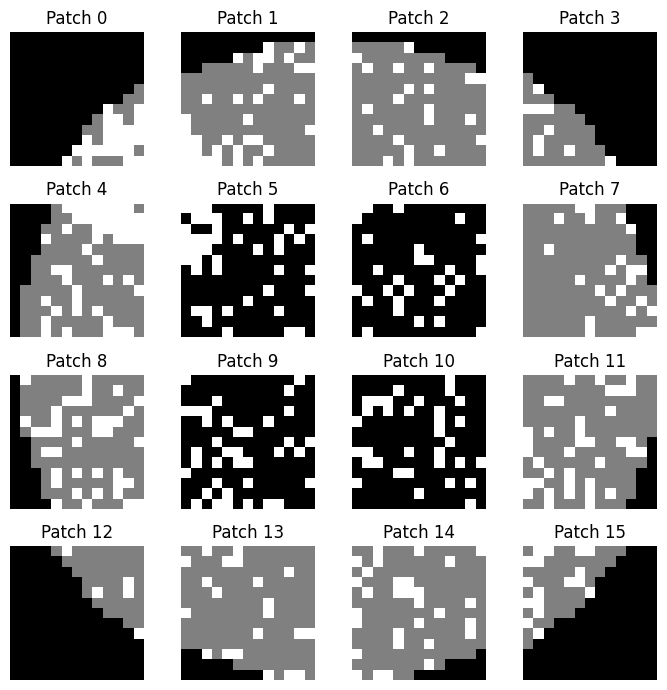

In [ ]:
IMAGE_SIZE = 52
PATCH_SIZE = 13
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

print(f"Image size: {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Patch size: {PATCH_SIZE} x {PATCH_SIZE}")
print(f"Patches per image: {NUM_PATCHES}")

def show_patches(image, patch_size=13):
    if torch.is_tensor(image):
        image = image.squeeze().cpu().numpy()
    else:
        image = np.asarray(image).squeeze()

    h, w = image.shape
    patches = image.reshape(
        h // patch_size, patch_size,
        w // patch_size, patch_size
    ).transpose(0, 2, 1, 3).reshape(-1, patch_size, patch_size)

    fig, axes = plt.subplots(4, 4, figsize=(7, 7))
    for i, (ax, patch) in enumerate(zip(axes.ravel(), patches)):
        ax.imshow(patch, cmap="gray")
        ax.set_title(f"Patch {i}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_patches(x_test[250])


# 7. PyTorch Vision Transformer

這個 `WaferViT` 對應原始 TensorFlow `vis_transformer.create_model()`：

```text
52×52×1
   ↓
16 patches (13×13)
   ↓
Linear projection → 96
   ↓
16 × Transformer Encoder
   ├─ LayerNorm
   ├─ 4-head Self Attention
   ├─ residual
   ├─ LayerNorm
   ├─ MLP 96 → 192 → 96
   └─ residual
   ↓
LayerNorm + Flatten
   ↓
MLP 2048 → 1024
   ↓
8 logits
```

PyTorch 使用 `TransformerEncoderLayer`，並設定 `norm_first=False`，讓 LayerNorm / Attention / residual 的順序對應原始 Keras block。

In [ ]:
class WaferViT(nn.Module):
    def __init__(
        self,
        image_size=52,
        patch_size=13,
        in_channels=1,
        num_classes=8,
        projection_dim=96,
        num_heads=4,
        transformer_layers=16,
        transformer_mlp_dim=192,
        classifier_hidden=(2048, 1024),
        attention_dropout=0.1,
        classifier_dropout=0.5,
    ):
        super().__init__()

        assert image_size % patch_size == 0
        assert projection_dim % num_heads == 0

        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        # Equivalent to extracting non-overlapping patches and
        # applying a Dense(projection_dim).
        self.patch_embed = nn.Conv2d(
            in_channels,
            projection_dim,
            kernel_size=patch_size,
            stride=patch_size,
            bias=True
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(1, self.num_patches, projection_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=projection_dim,
            nhead=num_heads,
            dim_feedforward=transformer_mlp_dim,
            dropout=attention_dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_layers
        )

        self.encoder_norm = nn.LayerNorm(projection_dim, eps=1e-6)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(self.num_patches * projection_dim, classifier_hidden[0]),
            nn.GELU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_hidden[0], classifier_hidden[1]),
            nn.GELU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_hidden[1], num_classes)
        )

        nn.init.trunc_normal_(self.position_embedding, std=0.02)

    def get_patches(self, x):
        # [B, 1, 52, 52] -> [B, 16, 13*13]
        patches = x.unfold(2, self.patch_size, self.patch_size)
        patches = patches.unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous()
        patches = patches.permute(0, 2, 3, 1, 4, 5)
        patches = patches.reshape(x.size(0), self.num_patches, -1)
        return patches

    def forward(self, x):
        # Patch embedding:
        # [B, 1, 52, 52] -> [B, 96, 4, 4]
        x = self.patch_embed(x)

        # [B, 96, 4, 4] -> [B, 16, 96]
        x = x.flatten(2).transpose(1, 2)

        # Position embedding
        x = x + self.position_embedding

        # Transformer blocks
        x = self.transformer(x)

        # Final LayerNorm
        x = self.encoder_norm(x)

        # MLP classifier
        logits = self.classifier(x)

        return logits


model = WaferViT().to(device)

print(model)
print("\nTrainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))


WaferViT(
  (patch_embed): Conv2d(1, 96, kernel_size=(13, 13), stride=(13, 13))
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-15): 16 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=192, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=192, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (encoder_norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=1536, o

## 8. Check Tensor Shapes Before Training

先用一個 batch 做 forward pass，避免直接開始長時間訓練後才發現 shape 問題。

In [ ]:
model.eval()

with torch.no_grad():
    logits = model(sample_x.to(device))

print("Input shape :", sample_x.shape)
print("Output shape:", logits.shape)
print("Expected    :", (sample_x.shape[0], 8))


Input shape : torch.Size([128, 1, 52, 52])
Output shape: torch.Size([128, 8])
Expected    : (128, 8)


## 9. Training Configuration

原 TensorFlow：
- Adam
- initial learning rate = `1e-3`
- ExponentialDecay
- `binary_crossentropy`
- 45 epochs
- checkpoint by validation accuracy

PyTorch 版本保留這些核心設定。`BCEWithLogitsLoss` 數值上比 `sigmoid + BCELoss` 更穩定。

In [ ]:
EPOCHS = 45
LEARNING_RATE = 1e-3
DECAY_STEPS = 10_000
DECAY_RATE = 0.9

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# Equivalent to TensorFlow ExponentialDecay:
# lr = initial_lr * decay_rate ** (global_step / decay_steps)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: DECAY_RATE ** (step / DECAY_STEPS)
)

checkpoint_path = "/content/best_wafer_vit.pt"
history_path = "/content/wafer_vit_history.pkl"


## 10. Metrics

原始模型是 **multi-label classification**，因此不能用一般 single-class `argmax` accuracy 取代。

這裡提供三個指標：
- **Exact Match Accuracy**：8 個 defect labels 必須全部預測正確
- **Label Accuracy**：逐一計算 8 個 defect label 的 binary accuracy
- **Validation Loss**

threshold 預設使用 0.5。

In [ ]:
def multilabel_metrics(logits, labels, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    exact_match = (preds == labels).all(dim=1).float().mean().item()
    label_accuracy = (preds == labels).float().mean().item()

    return exact_match, label_accuracy


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_exact = 0.0
    total_label_acc = 0.0
    total_samples = 0

    for images_batch, labels_batch in loader:
        images_batch = images_batch.to(device, non_blocking=True)
        labels_batch = labels_batch.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(images_batch)
        loss = criterion(logits, labels_batch)

        if is_train:
            loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

        batch_size = images_batch.size(0)
        exact_acc, label_acc = multilabel_metrics(logits, labels_batch)

        total_loss += loss.item() * batch_size
        total_exact += exact_acc * batch_size
        total_label_acc += label_acc * batch_size
        total_samples += batch_size

    return (
        total_loss / total_samples,
        total_exact / total_samples,
        total_label_acc / total_samples
    )


## 11. Train the ViT

最佳模型會根據 validation exact-match accuracy 儲存到：

`/content/best_wafer_vit.pt`

如果只想先確認 Colab 可以跑通，可以先把 `EPOCHS = 45` 改成 `3`。

In [ ]:
best_val_exact = -1.0
history = {
    "train_loss": [],
    "train_exact": [],
    "train_label_acc": [],
    "val_loss": [],
    "val_exact": [],
    "val_label_acc": [],
    "lr": []
}

for epoch in range(EPOCHS):
    train_loss, train_exact, train_label_acc = run_epoch(
        model, train_loader, criterion, optimizer, scheduler
    )

    with torch.no_grad():
        val_loss, val_exact, val_label_acc = run_epoch(
            model, val_loader, criterion
        )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_exact"].append(train_exact)
    history["train_label_acc"].append(train_label_acc)
    history["val_loss"].append(val_loss)
    history["val_exact"].append(val_exact)
    history["val_label_acc"].append(val_label_acc)
    history["lr"].append(current_lr)

    if val_exact > best_val_exact:
        best_val_exact = val_exact
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch + 1,
                "val_exact": val_exact,
                "history": history,
            },
            checkpoint_path
        )

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Exact {train_exact:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Exact {val_exact:.4f} | "
        f"LR {current_lr:.6g}"
    )

print("\nBest validation exact-match accuracy:",
      f"{best_val_exact*100:.2f}%")
print("Checkpoint:", checkpoint_path)

with open(history_path, "wb") as f:
    pickle.dump(history, f)


Epoch 01/45 | Train Loss 0.5194 | Train Exact 0.0259 | Val Loss 0.5094 | Val Exact 0.0227 | LR 0.000997748
Epoch 02/45 | Train Loss 0.5083 | Train Exact 0.0266 | Val Loss 0.5096 | Val Exact 0.0227 | LR 0.000995501
Epoch 03/45 | Train Loss 0.5078 | Train Exact 0.0270 | Val Loss 0.5095 | Val Exact 0.0266 | LR 0.000993259
Epoch 04/45 | Train Loss 0.5077 | Train Exact 0.0252 | Val Loss 0.5096 | Val Exact 0.0266 | LR 0.000991022
Epoch 05/45 | Train Loss 0.5077 | Train Exact 0.0263 | Val Loss 0.5093 | Val Exact 0.0227 | LR 0.00098879
Epoch 06/45 | Train Loss 0.5074 | Train Exact 0.0250 | Val Loss 0.5092 | Val Exact 0.0227 | LR 0.000986563
Epoch 07/45 | Train Loss 0.5075 | Train Exact 0.0254 | Val Loss 0.5094 | Val Exact 0.0266 | LR 0.000984341
Epoch 08/45 | Train Loss 0.5075 | Train Exact 0.0259 | Val Loss 0.5105 | Val Exact 0.0266 | LR 0.000982124
Epoch 09/45 | Train Loss 0.5077 | Train Exact 0.0262 | Val Loss 0.5098 | Val Exact 0.0227 | LR 0.000979912
Epoch 10/45 | Train Loss 0.5078 | Trai

## 12. Plot Training History

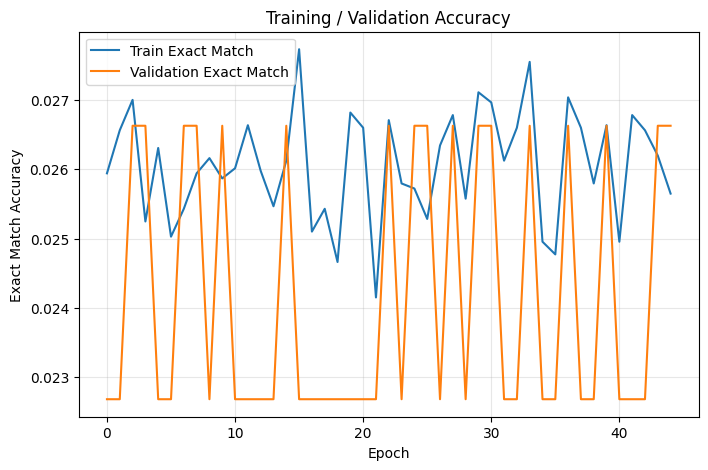

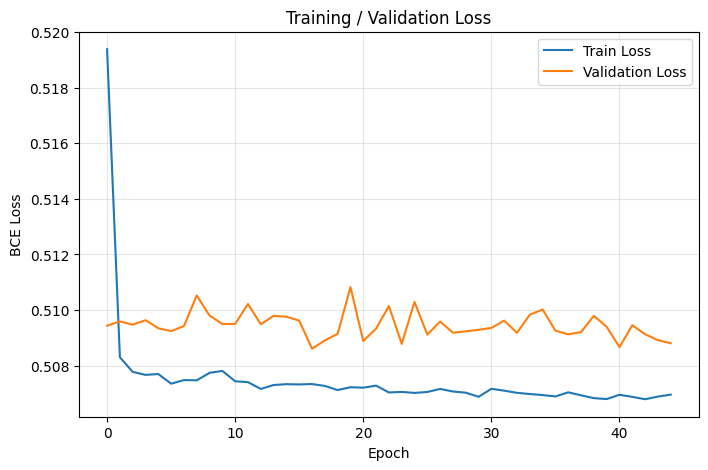

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_exact"], label="Train Exact Match")
plt.plot(history["val_exact"], label="Validation Exact Match")
plt.xlabel("Epoch")
plt.ylabel("Exact Match Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 13. Load Best Model and Evaluate on Test Set

In [ ]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_loss, test_exact, test_label_acc = run_epoch(
    model, test_loader, criterion
)

print(f"Test loss:              {test_loss:.4f}")
print(f"Test exact-match acc:   {test_exact*100:.2f}%")
print(f"Test label accuracy:    {test_label_acc*100:.2f}%")


Test loss:              0.5078
Test exact-match acc:   2.89%
Test label accuracy:    71.22%


## 14. Classification Report for Each Defect Type

因為這是 multi-label classification，這裡將每一個 defect 當成一個 binary classification，分別輸出 precision / recall / F1。

In [ ]:
def collect_predictions(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images_batch, labels_batch in loader:
            logits = model(images_batch.to(device))
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels_batch.numpy())

    return np.concatenate(all_probs), np.concatenate(all_labels)


test_probs, test_labels = collect_predictions(model, test_loader)
test_preds = (test_probs >= 0.5).astype(np.int32)

target_names = [
    "Center", "Donut", "Edge_Loc", "Edge_Ring",
    "Loc", "Near_Full", "Scratch", "Random"
]

print(
    classification_report(
        test_labels.astype(int),
        test_preds,
        target_names=target_names,
        zero_division=0
    )
)


              precision    recall  f1-score   support

      Center       0.00      0.00      0.00      2587
       Donut       0.00      0.00      0.00      2377
    Edge_Loc       0.00      0.00      0.00      2605
   Edge_Ring       0.00      0.00      0.00      2404
         Loc       0.00      0.00      0.00      3604
   Near_Full       0.00      0.00      0.00        34
     Scratch       0.00      0.00      0.00      3713
      Random       0.00      0.00      0.00       179

   micro avg       0.00      0.00      0.00     17503
   macro avg       0.00      0.00      0.00     17503
weighted avg       0.00      0.00      0.00     17503
 samples avg       0.00      0.00      0.00     17503



## 15. Multi-label Confusion Matrices

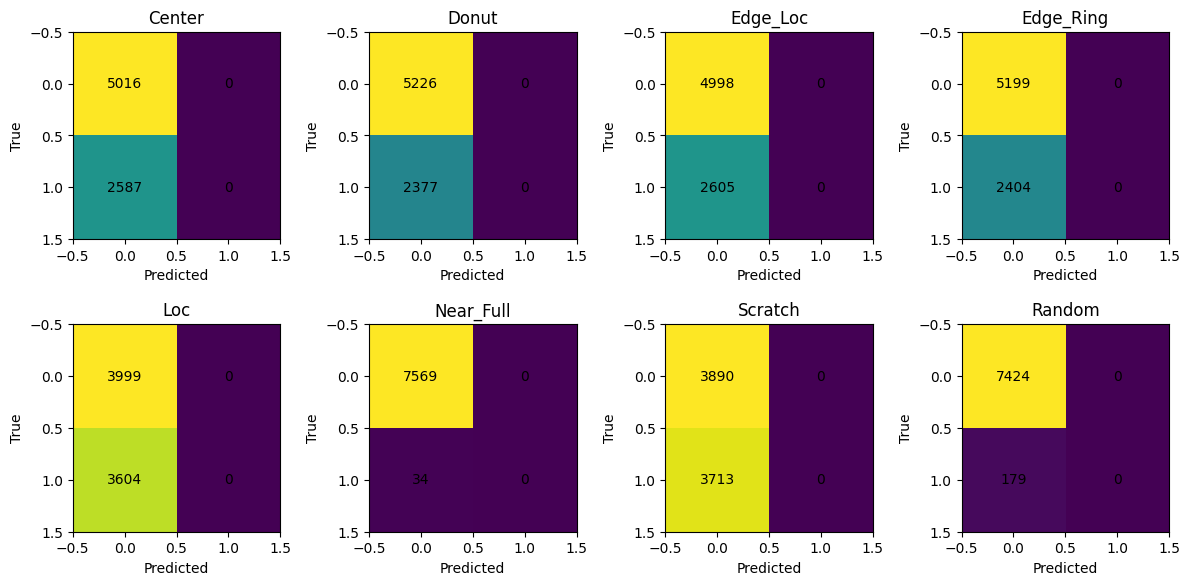

In [ ]:
mcm = multilabel_confusion_matrix(
    test_labels.astype(int),
    test_preds
)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, cm, name in zip(axes.ravel(), mcm, target_names):
    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha="center", va="center")

plt.tight_layout()
plt.show()


## 16. Prediction on Individual Wafer Maps

這部分對應原 TensorFlow Notebook 的 prediction cells。

輸出：
- Ground truth
- 8 個 defect 的 probability
- threshold 後的 prediction
- 讀成人類可讀的 defect type

Test image index: 900


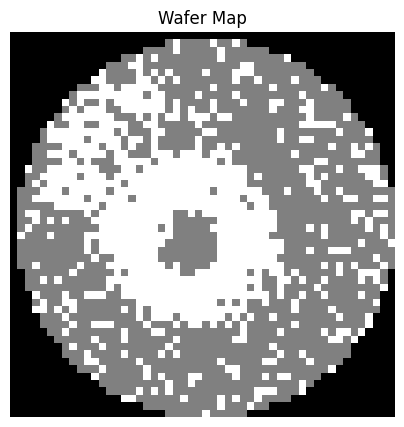

Ground truth: Donut, Loc
Prediction probabilities:
  Center    : 0.3123
  Donut     : 0.2966
  Edge_Loc  : 0.3808
  Edge_Ring : 0.2931
  Loc       : 0.4820
  Near_Full : 0.0030
  Scratch   : 0.4988
  Random    : 0.0179
Predicted: Normal wafer
Test image index: 500


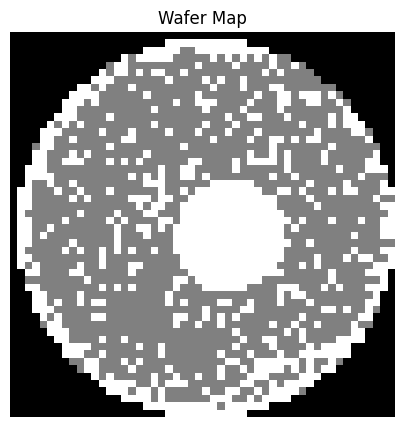

Ground truth: Center, Edge_Loc, Scratch
Prediction probabilities:
  Center    : 0.3123
  Donut     : 0.2966
  Edge_Loc  : 0.3808
  Edge_Ring : 0.2931
  Loc       : 0.4820
  Near_Full : 0.0030
  Scratch   : 0.4988
  Random    : 0.0179
Predicted: Normal wafer
Test image index: 3000


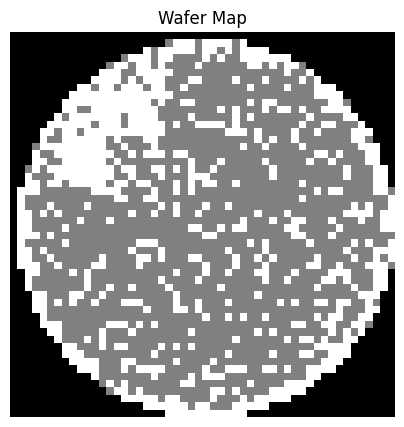

Ground truth: Edge_Ring, Loc
Prediction probabilities:
  Center    : 0.3123
  Donut     : 0.2966
  Edge_Loc  : 0.3808
  Edge_Ring : 0.2931
  Loc       : 0.4820
  Near_Full : 0.0030
  Scratch   : 0.4988
  Random    : 0.0179
Predicted: Normal wafer


In [ ]:
def decode_prediction(pred_binary):
    if np.sum(pred_binary) == 0:
        return "Normal wafer"

    names = [
        name for name, value in zip(target_names, pred_binary)
        if value == 1
    ]
    return ", ".join(names)


def predict_one(model, image, true_label=None, threshold=0.5):
    model.eval()

    dataset = WaferDataset(
        np.expand_dims(image, 0),
        np.zeros((1, 8), dtype=np.float32)
    )
    image_tensor, _ = dataset[0]

    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(device))
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    pred_binary = (probs >= threshold).astype(int)

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title("Wafer Map")
    plt.show()

    if true_label is not None:
        print("Ground truth:", data_loader.read_label(true_label))

    print("Prediction probabilities:")
    for name, p in zip(target_names, probs):
        print(f"  {name:10s}: {p:.4f}")

    print("Predicted:", decode_prediction(pred_binary))

    return probs, pred_binary


for pred_img_num in [900, 500, 3000]:
    print("=" * 60)
    print("Test image index:", pred_img_num)
    predict_one(
        model,
        x_test[pred_img_num],
        y_test[pred_img_num]
    )


## 17. Optional: Evaluate All 38 MixedWM38 Patterns

MixedWM38 的 8-bit multi-label 組合對應 38 種 pattern（包含 Normal）。

這裡不把問題改成 38-class softmax，而是維持原始 ViT 的 8-output multi-label 設計，再將 8-bit prediction 轉成 pattern code。

這樣可以直接觀察模型對 38 種 wafer pattern 的辨識情況。

38-pattern exact-match accuracy: 2.89%


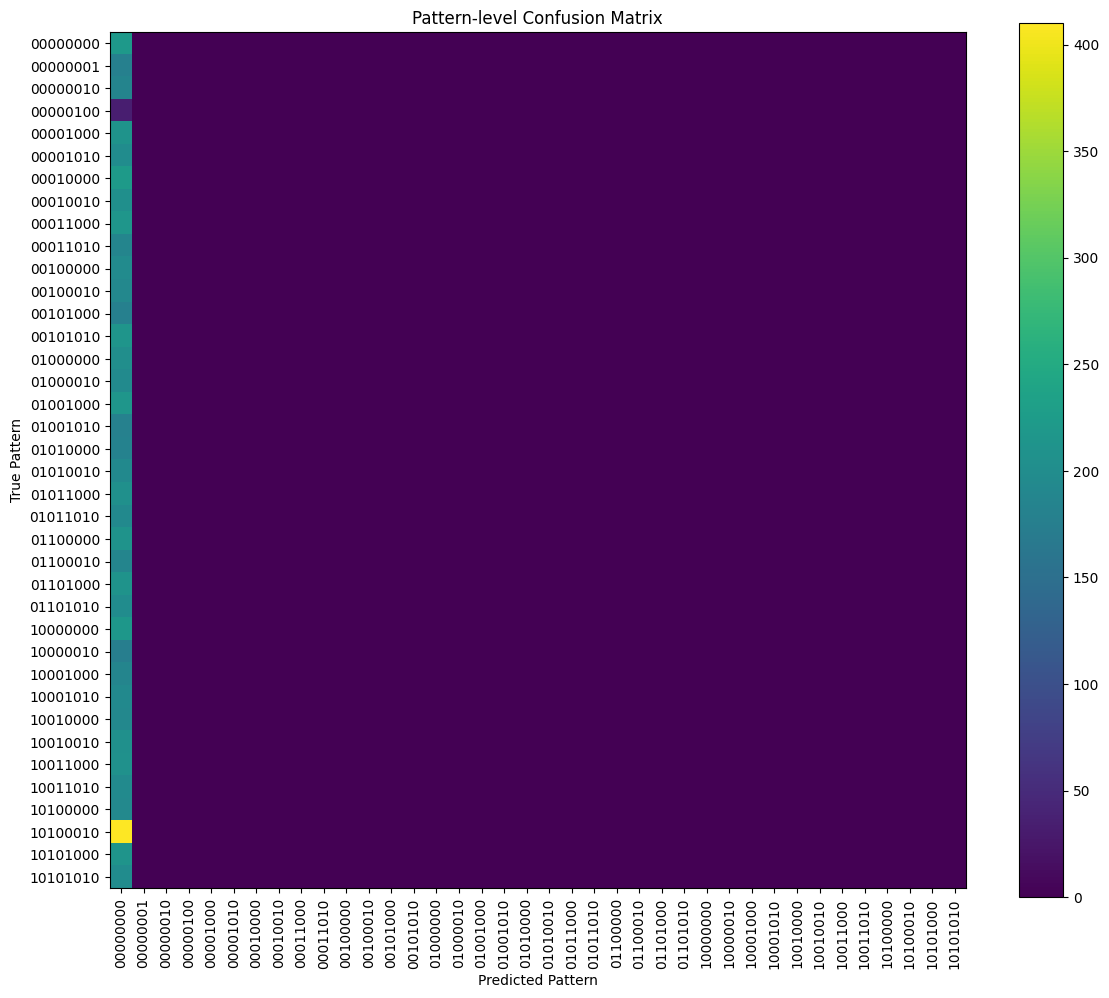

In [ ]:
def label_to_code(label):
    return "".join(str(int(v)) for v in label)


true_codes = np.array([label_to_code(y) for y in test_labels])
pred_codes = np.array([label_to_code(y) for y in test_preds])

pattern_exact = np.mean(true_codes == pred_codes)

print(f"38-pattern exact-match accuracy: {pattern_exact*100:.2f}%")

# Pattern-level report
pattern_labels = sorted(np.unique(np.concatenate([true_codes, pred_codes])))

from sklearn.metrics import confusion_matrix

cm_pattern = confusion_matrix(
    true_codes,
    pred_codes,
    labels=pattern_labels
)

plt.figure(figsize=(12, 10))
plt.imshow(cm_pattern)
plt.title("Pattern-level Confusion Matrix")
plt.xlabel("Predicted Pattern")
plt.ylabel("True Pattern")
plt.xticks(range(len(pattern_labels)), pattern_labels, rotation=90)
plt.yticks(range(len(pattern_labels)), pattern_labels)
plt.colorbar()
plt.tight_layout()
plt.show()


## 18. Save the Final Model

除了 best checkpoint，也可以另外輸出一份最終可攜帶的 PyTorch state dict。

In [ ]:
final_model_path = "/content/wafer_vit_final.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": {
            "image_size": 52,
            "patch_size": 13,
            "projection_dim": 96,
            "num_heads": 4,
            "transformer_layers": 16,
            "transformer_mlp_dim": 192,
            "num_classes": 8,
        },
        "label_names": target_names,
    },
    final_model_path
)

print("Saved:", final_model_path)


Saved: /content/wafer_vit_final.pth


# Notes

### 主要轉換對照

| TensorFlow / Keras | PyTorch |
|---|---|
| `tf.image.extract_patches` | `Conv2d(kernel=stride=13)` / `unfold` |
| `layers.Dense(96)` | patch embedding `Conv2d` |
| `layers.Embedding` | learnable `position_embedding` |
| `layers.MultiHeadAttention` | `nn.TransformerEncoderLayer` |
| `layers.LayerNormalization` | `nn.LayerNorm` |
| `layers.Dense(..., activation=gelu)` | `nn.Linear + nn.GELU` |
| `sigmoid` | `torch.sigmoid()` only at inference |
| `binary_crossentropy` | `BCEWithLogitsLoss` |
| `keras.optimizers.Adam` | `torch.optim.Adam` |
| `ExponentialDecay` | `LambdaLR` |
| `ModelCheckpoint` | `torch.save()` |
| `model.predict()` | `model(...)` + `torch.sigmoid()` |

### 注意

這份版本是把**原本的 MixedWM38 TensorFlow ViT** 改成 PyTorch，而不是把模型改成 ResNet50。參考的 `ResNet50_Wafer_Map_Recognition.ipynb` 主要借用其 **Colab + kagglehub + PyTorch Dataset/DataLoader** 的資料處理方式。

因此模型本身仍然保持原 ViT 的 8-label multi-label 設計。